# Aprendizaje por refuerzo
## Entorno estacionario

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]

# Preferencias reales del usuario
# El algoritmo NO conoce estos valores
true_prob = np.array([0.2, 0.6, 0.8, 0.4])

n_actions = len(content)

# Estimación inicial de recompensa
Q = np.zeros(n_actions)

# Número de veces que cada acción ha sido seleccionada
N = np.zeros(n_actions)

epsilon = 0.1
T = 1000

rewards = []
actions = []

for t in range(T):

    # Exploration
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)

    # Exploitation
    else:
        action = np.argmax(Q)

    # Respuesta del usuario
    reward = np.random.rand() < true_prob[action]

    # Guardamos resultados
    rewards.append(reward)
    actions.append(action)

    # Actualizamos la estimación
    N[action] += 1
    Q[action] += (reward - Q[action]) / N[action]

In [4]:
for i in range(n_actions):
    print(
        content[i],
        " | valor real:", true_prob[i],
        " | valor aprendido:", round(Q[i], 3),
        " | veces mostrado:", int(N[i])
    )

Deportes  | valor real: 0.2  | valor aprendido: 0.2  | veces mostrado: 30
Noticias  | valor real: 0.6  | valor aprendido: 0.5  | veces mostrado: 30
Tecnología  | valor real: 0.8  | valor aprendido: 0.806  | veces mostrado: 907
Entretenimiento  | valor real: 0.4  | valor aprendido: 0.424  | veces mostrado: 33


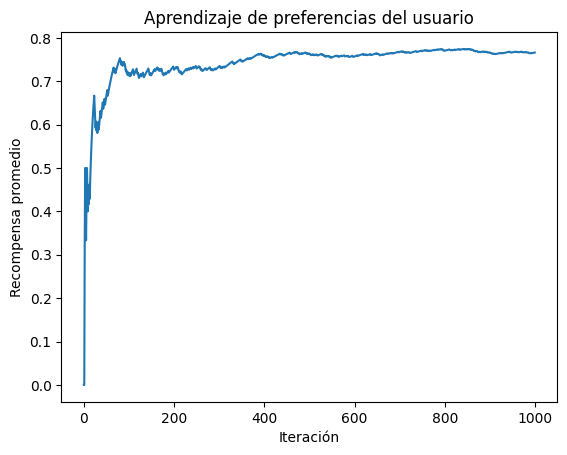

In [5]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio")
plt.title("Aprendizaje de preferencias del usuario")
plt.show()

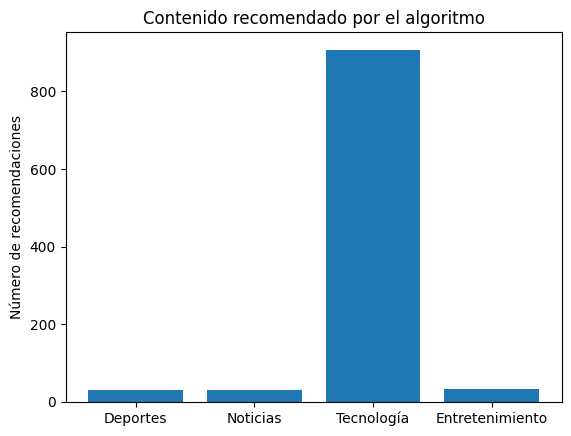

In [6]:
counts = [actions.count(i) for i in range(n_actions)]

plt.bar(content, counts)
plt.ylabel("Número de recomendaciones")
plt.title("Contenido recomendado por el algoritmo")
plt.show()

#Entorno no-estacionario

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]
n_actions = len(content)

epsilon = 0.1
alpha = 0.1
T = 1000

Q = np.zeros(n_actions)
N = np.zeros(n_actions)

rewards = []
actions = []
best_prob_over_time = []

for t in range(T):

    # Preferencias reales del usuario cambian a mitad del experimento
    if t < 500:
        true_prob = np.array([0.2, 0.5, 0.8, 0.3])
    else:
        true_prob = np.array([0.2, 0.4, 0.3, 0.9])

    best_prob_over_time.append(np.max(true_prob))

    # epsilon-greedy
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)
    else:
        action = np.argmax(Q)

    # Recompensa
    reward = 1 if np.random.rand() < true_prob[action] else 0

    actions.append(action)
    rewards.append(reward)
    N[action] += 1

    # Actualización para caso no estacionario
    Q[action] = Q[action] + alpha * (reward - Q[action])

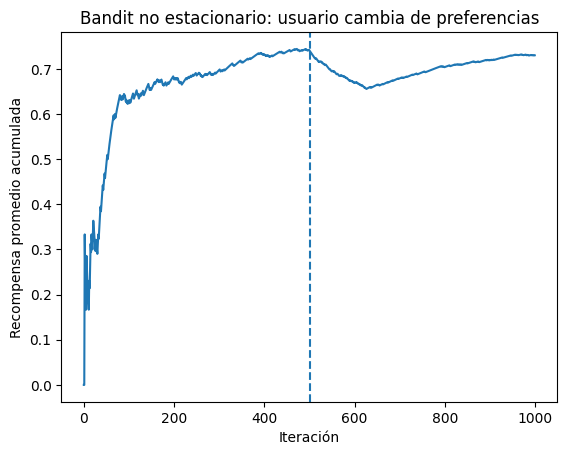

In [8]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.axvline(500, linestyle="--")
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio acumulada")
plt.title("Bandit no estacionario: usuario cambia de preferencias")
plt.show()

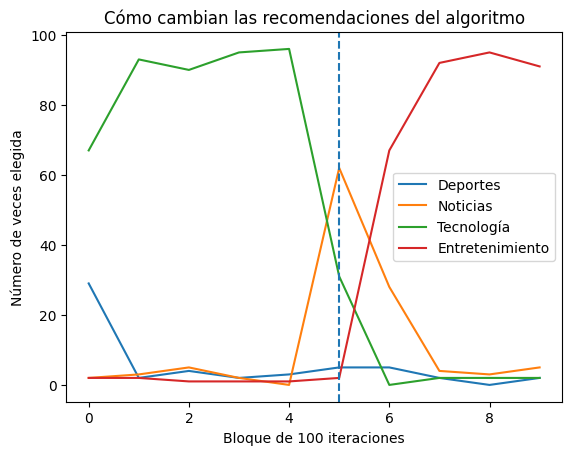

In [9]:
window = 100
chosen_actions = []

for start in range(0, T, window):
    block = actions[start:start+window]
    counts = [block.count(a) for a in range(n_actions)]
    chosen_actions.append(counts)

chosen_actions = np.array(chosen_actions)

for a in range(n_actions):
    plt.plot(chosen_actions[:, a], label=content[a])

plt.axvline(5, linestyle="--")  # porque 500 = 5 bloques de 100
plt.xlabel("Bloque de 100 iteraciones")
plt.ylabel("Número de veces elegida")
plt.title("Cómo cambian las recomendaciones del algoritmo")
plt.legend()
plt.show()

# Actividades para hoy

1. Para el entorno estacionario y para el entorno no-estacionario probar con diferentes valores de $\epsilon$ y describir cómo afecta el algoritmo.

2. Para el entorno estacionario usar tasa de aprendizaje constante y describir lo observado con el desempeño del algoritmo.

3. Para el entorno no estacionario utilizar como tasa de aprendizaje $1/N(a)$ y describir lo observado con el desempeño del algoritmo.

Actividad 1: Comparativa de valores de $\epsilon$ (Entornos Estacionario y No-Estacionario)

Para evaluar el impacto de $\epsilon$, probaremos con valores extremos y moderados: $\epsilon = 0.0$ (explotación pura / greedy), $\epsilon = 0.1$ (exploración balanceada) y $\epsilon = 0.5$ (exploración alta).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]
n_actions = len(content)
T = 1000
epsilons = [0.0, 0.1, 0.5]


def run_simulation(stationary=True, epsilon=0.1, alpha_constant=False):
    true_prob = np.array([0.2, 0.6, 0.8, 0.4])
    Q = np.zeros(n_actions)
    N = np.zeros(n_actions)
    rewards = []

    for t in range(T):
        # En entorno no-estacionario, las probabilidades reales cambian con el tiempo (walk aleatorio)
        if not stationary:
            true_prob += np.random.normal(0, 0.01, size=n_actions)
            true_prob = np.clip(true_prob, 0.0, 1.0)

        # Selección de acción (e-greedy)
        if np.random.rand() < epsilon:
            action = np.random.randint(n_actions)
        else:
            action = np.argmax(Q)

        reward = 1.0 if np.random.rand() < true_prob[action] else 0.0
        rewards.append(reward)

        N[action] += 1

        # Tasa de aprendizaje
        if alpha_constant:
            alpha = 0.1
        else:
            alpha = 1.0 / N[action]

        Q[action] += alpha * (reward - Q[action])

    return np.cumsum(rewards) / np.arange(1, T + 1)

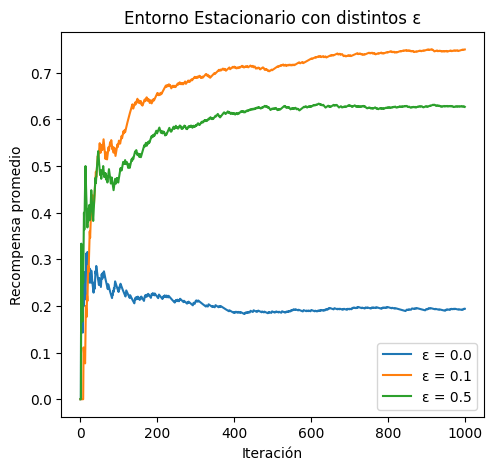

In [2]:
# Gráficas para Entorno Estacionario
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for eps in epsilons:
    res = run_simulation(stationary=True, epsilon=eps)
    plt.plot(res, label=f"ε = {eps}")
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio")
plt.title("Entorno Estacionario con distintos ε")
plt.legend()

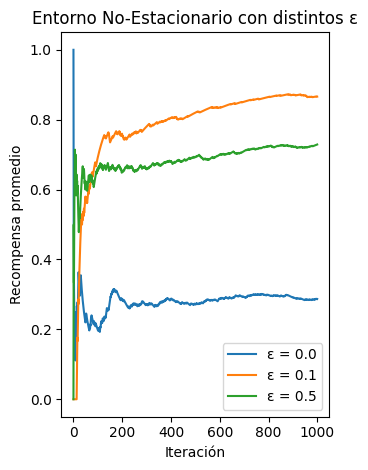

In [3]:
# Gráficas para Entorno No-Estacionario
plt.subplot(1, 2, 2)
for eps in epsilons:
    res = run_simulation(stationary=False, epsilon=eps)
    plt.plot(res, label=f"ε = {eps}")
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio")
plt.title("Entorno No-Estacionario con distintos ε")
plt.legend()

plt.tight_layout()
plt.show()

Descripción de lo observado:

$\epsilon = 0.0$ (Greedy): En ambos entornos queda atrapado rápidamente en subóptimos si la primera acción seleccionada da una recompensa positiva inicial, impidiendo descubrir la mejor opción ("Tecnología" con $0.8$).

$\epsilon = 0.1$ (Balance óptimo): Logra explorar lo suficiente al inicio para encontrar la acción óptima y luego dedica el $90\%$ del tiempo a explotarla, obteniendo el mejor desempeño promedio a largo plazo.

$\epsilon = 0.5$ (Alta exploración): Encuentra la mejor acción rápidamente, pero degrada su rendimiento global porque pasa el $50\%$ del tiempo eligiendo acciones al azar (incluyendo las de menor recompensa).Entorno No-Estacionario: La necesidad de $\epsilon > 0$ es crítica; si el entorno cambia y la mejor acción deja de serlo, solo con exploración continua ($\epsilon > 0$) el algoritmo puede descubrir las nuevas preferencias

Actividad 2: Tasa de aprendizaje constante ($\alpha = 0.1$) en Entorno Estacionario

Sustituimos el promedio incremental $1/N(a)$ por un valor constante $\alpha = 0.1$:

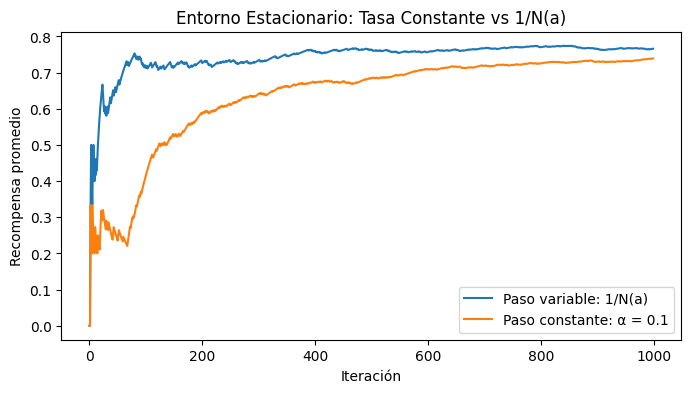

In [4]:
np.random.seed(42)

# Ejecución con promedio muestral (1/N)
avg_reward_sample = run_simulation(
    stationary=True, epsilon=0.1, alpha_constant=False
)

# Ejecución con tasa constante (alpha = 0.1)
avg_reward_constant = run_simulation(
    stationary=True, epsilon=0.1, alpha_constant=True
)

plt.figure(figsize=(8, 4))
plt.plot(avg_reward_sample, label="Paso variable: 1/N(a)")
plt.plot(avg_reward_constant, label="Paso constante: α = 0.1")
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio")
plt.title("Entorno Estacionario: Tasa Constante vs 1/N(a)")
plt.legend()
plt.show()

Descripción de lo observado:

En un entorno estacionario, el promedio muestral ($1/N(a)$) converge teóricamente al valor real exacto de la recompensa esperada conforme $N \to \infty$, reduciendo la varianza a cero.

Al usar una tasa constante ($\alpha = 0.1$), el algoritmo le da más peso a las recompensas más recientes (promedio ponderado exponencial). En un entorno fijo, esto introduce ruido persistente en las estimaciones de $Q(a)$ incluso tras muchas iteraciones, haciendo que la curva de recompensa promedio fluctúe ligeramente por debajo del método $1/N(a)$.

Actividad 3: Tasa de aprendizaje $1/N(a)$ en Entorno No-Estacionario

Evaluamos la actualización decayente $1/N(a)$ cuando las probabilidades reales del entorno cambian con el tiempo:

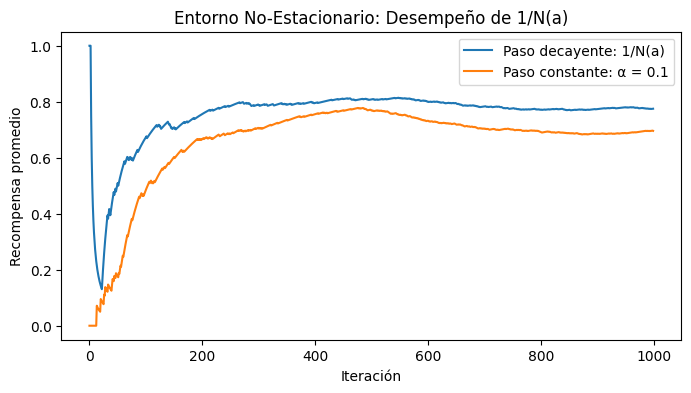

In [5]:
np.random.seed(42)

# Entorno No-Estacionario con 1/N(a)
avg_reward_nonstat_sample = run_simulation(
    stationary=False, epsilon=0.1, alpha_constant=False
)

# Entorno No-Estacionario con α = 0.1
avg_reward_nonstat_constant = run_simulation(
    stationary=False, epsilon=0.1, alpha_constant=True
)

plt.figure(figsize=(8, 4))
plt.plot(avg_reward_nonstat_sample, label="Paso decayente: 1/N(a)")
plt.plot(avg_reward_nonstat_constant, label="Paso constante: α = 0.1")
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio")
plt.title("Entorno No-Estacionario: Desempeño de 1/N(a)")
plt.legend()
plt.show()

Descripción de lo observado:

Al utilizar $1/N(a)$ en un entorno no-estacionario, el desempeño se degrada drásticamente con el tiempo.

A medida que $N(a)$ crece, el tamaño de paso $\alpha_t = 1/N(a)$ se vuelve extremadamente pequeño ($\to 0$). Esto hace que el algoritmo "cierre sus estimaciones" y sea incapaz de actualizar $Q(a)$ cuando las preferencias del usuario cambian.

Conclusión: La tasa $1/N(a)$ asume que las recompensas pasadas son tan válidas como las presentes, lo cual falla en entornos dinámicos donde se requiere una tasa constante $\alpha$ para olvidar las recompensas antiguas y adaptarse a los cambios.